# Single-model train/val report

Loads **one specific trained checkpoint** (set `RUN_ID` below) and evaluates it
on both its training set and its held-out validation set: recomputed
AP/MAE/MAE-skill/Pearson metrics (the ones the current objective uses), per-class
statistic heatmaps, a confusion matrix,
regression-vs-classification scatters, and per-class predicted-probability
distributions. Figures are defined once as reusable functions, then run twice
-- a **Train** section and a **Validation** section -- so the same report is
directly comparable across both splits. Each section has its own
`SAVE_*_FIGS` toggle (default `False`); when enabled every figure in that
section is written to `plots/{run_id}/{train|val}/{figure_name}.png`. This is
inference/evaluation only -- for sweep-wide hyperparameter-importance analysis
across many runs, see `analyze_sweep.ipynb` instead.

**Assumes the current 4-class scheme** (`["0-3.5","3.5-5","5-7.5","7.5+"]`,
grouped weighting `WEIGHT_GROUPS`, `OBJECTIVE_CLASSES` excluding `7.5+`). The
Validation table reconstructs the checkpoint's stored `ap_star` / `pearson_star`
/ `mae_skill_star` / `goal_metric` as a correctness check -- they should match
the training-time values printed on load.

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.stats import pearsonr, spearmanr
from sklearn.calibration import calibration_curve
from sklearn.metrics import r2_score, confusion_matrix

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "sweeps" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))
RUNS_DIR = REPO_ROOT / "runs"

from model import load_checkpoint
from data_utils import build_split_arrays, load_ecfp_precomputed, CACHE_DIR
from normalization import denormalize_pprop
from metrics import (
    compute_metrics,
    compute_class_mae_metrics,
    compute_class_pearson_metrics,
    compute_weighted_regression_stats,
)
# Grouped inverse-frequency weighting (WEIGHT_GROUPS) + the objective-class set
# are what the current training procedure uses; import them so every weighted
# statistic / AP aggregate here matches what the sweep logged. The confusion
# matrix is now built locally, so plot_confusion_matrix is no longer imported.
from losses import grouped_frequency_weights, sample_weights_from_classes
from make_splits import WEIGHT_GROUPS, OBJECTIVE_CLASSES
# forward_full/EVAL_CHUNK are the two-tower-aware chunked forward pass
# sweep_train.py's own evaluate() uses (X = MiniMol block, E = ECFP block or
# None); reusing them here (rather than a single model(X) call) keeps the
# full train/val forward pass from materializing O(N x width) activations --
# the same OOM risk the ECFP tower introduced during training. Importing
# sweep_train is side-effect-free: main() only runs under __main__.
from sweep_train import forward_full, EVAL_CHUNK

# Fixed point alpha for the regression scatters -- constant across whole-set
# and every per-class figure so opacity means the same thing everywhere and
# figures are visually comparable (rather than being rescaled by each
# subset's own point count).
SCATTER_ALPHA = 0.05

## Pick the run to evaluate

Set `RUN_ID` to a `runs/<run_id>/` directory containing `final_model.pt` +
`final_meta.json` (e.g. copy a run_id from `analyze_sweep.ipynb`'s top-N table,
or any completed run under `runs/`).

In [2]:
# NOTE: this notebook now assumes the current 4-class scheme (class_names =
# ["0-3.5","3.5-5","5-7.5","7.5+"], WEIGHT_GROUPS/OBJECTIVE_CLASSES). Old 6-class
# runs load silently but produce wrong numbers (and grouped_frequency_weights
# will raise on the class-count mismatch), so pick a run with n_classes == 4.
# Two-tower (arch == "two_tower") checkpoints are handled automatically below;
# single-tower (MiniMol-only) checkpoints still work unchanged.
RUN_ID = "jlwzehi6"  # <-- edit me (must be a post-rebin 4-class run)

## Load checkpoint

The split to evaluate on is read directly off the checkpoint's own
`config["split_dir"]`, so this always reconstructs the exact train/val split
that run was trained on -- never a mismatched split.

In [3]:
ckpt_path = RUNS_DIR / RUN_ID / "final_model.pt"
model, ckpt = load_checkpoint(ckpt_path, device="cpu")

split_dir = REPO_ROOT / ckpt["config"]["split_dir"]
class_names = ckpt["class_names"]
norm_stats = ckpt.get("norm_stats", {"strategy": "none"})
use_ecfp = bool(ckpt["config"].get("use_ecfp", 0))
arch = ckpt.get("arch", "single_tower")
ecfp_radius = ckpt["config"].get("ecfp_radius", 2)
ecfp_nbits = ckpt["config"].get("ecfp_nbits", 2048)

if ckpt["config"].get("n_classes") != 4:
    print(f"WARNING: n_classes={ckpt['config'].get('n_classes')} != 4 -- this notebook "
          f"assumes the current 4-class scheme; metrics below will be wrong.\n")

print(f"run_id: {RUN_ID}")
print(f"split_dir: {split_dir}")
print(f"epoch: {ckpt.get('epoch')}")
print(f"pprop_norm: {norm_stats.get('strategy', 'none')}"
      + ("" if "norm_stats" in ckpt else "  (absent in checkpoint -> assuming raw/none, pre-normalization run)"))
print(f"arch: {arch}")
print(f"use_ecfp: {use_ecfp}" + (f"  (radius={ecfp_radius}, n_bits={ecfp_nbits})" if use_ecfp else ""))
print("config:")
print(json.dumps(ckpt["config"], indent=2))
print()
# The current sweep_train stores the goal_metric and its three components on the
# checkpoint; print_metrics_table reconstructs these from a fresh forward pass.
print("checkpoint-reported val metrics (from training time):")
print(f"  val_goal_metric    = {ckpt.get('val_goal_metric')}")
print(f"  val_ap_star        = {ckpt.get('val_ap_star')}")
print(f"  val_pearson_star   = {ckpt.get('val_pearson_star')}")
print(f"  val_mae_skill_star = {ckpt.get('val_mae_skill_star')}")

run_id: jlwzehi6
split_dir: /home/ethan2/pProp_MLP/data/split_1
epoch: 19
pprop_norm: zscore
arch: two_tower
use_ecfp: True  (radius=2, n_bits=2048)
config:
{
  "split_dir": "data/split_1",
  "seed": 0,
  "use_ecfp": 1,
  "pprop_norm": "zscore",
  "proj_dim_minimol": 691,
  "proj_dim_ecfp": 985,
  "ecfp_radius": 2,
  "ecfp_nbits": 2048,
  "n_layers": 1,
  "hidden_dim": 624,
  "cls_n_layers": 0,
  "cls_hidden_dim": 480,
  "reg_n_layers": 3,
  "reg_hidden_dim": 232,
  "w_cls": 0.009832101692064502,
  "w_pair": 1.6736512729031836,
  "w_std": 0.026938899675505088,
  "huber_delta": 0.6652190394069013,
  "init_lr": 7.593711701608297e-05,
  "weight_decay": 0.0019381091842281255,
  "dropout": 0.4912928727589454,
  "batch_size": 4544,
  "epochs": 20,
  "eta_min": 1e-08,
  "in_dim": 2560,
  "minimol_dim": 512,
  "ecfp_dim": 2048,
  "n_classes": 4,
  "task": "dual",
  "arch": "two_tower",
  "class_weights": [
    0.1088,
    0.3177,
    3.4648,
    0.1088
  ],
  "weight_groups": [
    0,
    1,
 

In [4]:
embeddings = np.load(CACHE_DIR / "minimol_embeddings.npy")
smiles_index = (CACHE_DIR / "minimol_smiles.txt").read_text().splitlines()
minimol_dim = embeddings.shape[1]

# Two-tower checkpoints need the ECFP block loaded from its own per-radius cache
# (load_ecfp_precomputed, keyed by this checkpoint's ecfp_radius -- NOT the
# single-radius load_ecfp_features the main-branch/single-tower model used) and
# then split back apart from MiniMol, mirroring sweep_train.load_data exactly:
# build_split_arrays concatenates [MiniMol | ECFP] into one X, and the model's
# forward(x_minimol, x_ecfp) wants them as separate tensors, with ECFP kept as
# uint8 (binary -> lossless, 4x smaller resident than float32).
extra_features = [load_ecfp_precomputed(ecfp_radius, ecfp_nbits)] if use_ecfp else None
data = build_split_arrays(split_dir, embeddings, smiles_index, return_pprop=True,
                           extra_features=extra_features)


def split_minimol_ecfp(X):
    Xm = torch.as_tensor(X[:, :minimol_dim], dtype=torch.float32)
    E = torch.as_tensor(X[:, minimol_dim:].astype(np.uint8), dtype=torch.uint8) if use_ecfp else None
    return Xm, E


X_train, E_train = split_minimol_ecfp(data["X_train"])
X_val, E_val = split_minimol_ecfp(data["X_val"])
y_train, pprop_train = data["y_train"], data["pprop_train"]
y_val, pprop_val = data["y_val"], data["pprop_val"]

ecfp_desc = f" + {E_train.shape[1]}-dim ECFP (r={ecfp_radius})" if use_ecfp else ""
print(f"train set: {X_train.shape[0]} molecules, {X_train.shape[1]}-dim MiniMol{ecfp_desc}")
print(f"val set:   {X_val.shape[0]} molecules, {X_val.shape[1]}-dim MiniMol{ecfp_desc}")

train set: 530644 molecules, 512-dim MiniMol + 2048-dim ECFP (r=2)
val set:   93191 molecules, 512-dim MiniMol + 2048-dim ECFP (r=2)


## Plotting & metrics functions

Shared helpers used identically by both the **Train** and **Validation**
sections below, so the two report the exact same set of figures computed the
same way. Every plotting function takes a `save` flag; when `True` it also
writes the figure to `plots/{run_id}/{train|val}/{figure_name}.png`.

In [5]:
PLOTS_DIR = REPO_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)


def save_fig(fig, name, split_name, save):
    """Write `fig` to plots/{RUN_ID}/{split_name}/{name}.png if save is True."""
    if not save:
        return
    out_dir = PLOTS_DIR / RUN_ID / split_name
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / f"{name}.png", dpi=150, bbox_inches="tight")


def compute_split_predictions(X, E):
    """Run the model on split (X, E) -> (probs, preds, pred_pprop).

    Uses sweep_train's forward_full (X = MiniMol block, E = ECFP block or None)
    so the full train/val set is scored in EVAL_CHUNK-sized chunks -- the same
    chunking training-time evaluate() uses -- instead of one O(N x width)
    forward pass, which is what OOM'd on the two-tower model's wider ECFP
    tower. For single-tower (MiniMol-only) checkpoints E is None and
    forward_full degrades to a plain chunked forward.

    reg_out is in normalized units whenever this checkpoint was trained with
    pprop_norm != "none" -- denormalize via the checkpoint's own norm_stats so
    pred_pprop is always on the same raw pProp scale as the true `pprop` arrays
    it's compared against below.
    """
    cls_logits, reg_out = forward_full(model, X, E)
    probs = torch.softmax(cls_logits, dim=1).numpy()
    preds = probs.argmax(axis=1)
    pred_pprop = denormalize_pprop(reg_out.squeeze(-1), norm_stats).numpy()
    return probs, preds, pred_pprop


def print_metrics_table(y, pprop, probs, pred_pprop, class_names, split_label, ckpt_compare=None):
    """Compute + print the per-class/aggregate metrics table for one split.

    Everything here mirrors the current training objective (src/sweep_train.py):
    classification AP is aggregated over OBJECTIVE_CLASSES (the 7.5+ artifact
    class is still scored + reported per-class but excluded from the *_obj
    aggregates), and the weighted regression metrics use the grouped
    inverse-frequency scheme (WEIGHT_GROUPS) rather than plain per-class inverse
    frequency -- so weighted_mae / pearson_weighted / *_skill match what the
    sweep logged. The three goal_metric components are then reconstructed as
    `sweep_train` builds them:
        AP*        = 0.5*(macro_ap_obj + weighted_ap_obj)
        Pearson*   = 0.5*(pearson + pearson_weighted)
        MAE_skill* = 0.5*(mae_skill + weighted_mae_skill)
        goal_metric = AP* + 0.5*(Pearson* + MAE_skill*)
    When `ckpt_compare` is given they're checked against the checkpoint's own
    stored components -- the discriminating test that the whole pipeline (weights,
    weighting scheme, objective classes) reproduces the run.
    """
    m = compute_metrics(y, probs, class_names, objective_classes=OBJECTIVE_CLASSES)
    m.update(compute_class_mae_metrics(pprop, pred_pprop, y, class_names, groups=WEIGHT_GROUPS))
    pearson_m = compute_class_pearson_metrics(pprop, pred_pprop, y, class_names, groups=WEIGHT_GROUPS)

    per_class_df = pd.DataFrame({
        "class": class_names,
        "n": np.bincount(y, minlength=len(class_names)),
        "ap": [m["ap"][c] for c in class_names],
        "mae": [m["mae_per_class"][c] for c in class_names],
    }).set_index("class")

    ap_star = 0.5 * (m["macro_ap_obj"] + m["weighted_ap_obj"])
    pearson_star = 0.5 * (pearson_m["pearson"] + pearson_m["pearson_weighted"])
    mae_skill_star = 0.5 * (m["mae_skill"] + m["weighted_mae_skill"])
    goal_metric = ap_star + 0.5 * (pearson_star + mae_skill_star)

    summary = {
        "macro_ap_obj": m["macro_ap_obj"],
        "weighted_ap_obj": m["weighted_ap_obj"],
        "weighted_ap": m["weighted_ap"],
        "mae": m["mae"],
        "weighted_mae": m["weighted_mae"],
        "mae_skill": m["mae_skill"],
        "weighted_mae_skill": m["weighted_mae_skill"],
        "pearson": pearson_m["pearson"],
        "pearson_weighted": pearson_m["pearson_weighted"],
        "ap_star": ap_star,
        "pearson_star": pearson_star,
        "mae_skill_star": mae_skill_star,
        "goal_metric": goal_metric,
    }

    print(f"{split_label} per-class (AP + MAE; 7.5+ shown but excluded from *_obj):")
    display(per_class_df)
    print(f"\n{split_label} aggregate:")
    display(pd.Series(summary))

    if ckpt_compare is not None:
        print(f"\n{split_label} goal-metric decomposition vs. checkpoint-reported (training time):")
        print(f"  ap_star        = {ap_star:.4f}  (ckpt: {ckpt_compare.get('val_ap_star')})")
        print(f"  pearson_star   = {pearson_star:.4f}  (ckpt: {ckpt_compare.get('val_pearson_star')})")
        print(f"  mae_skill_star = {mae_skill_star:.4f}  (ckpt: {ckpt_compare.get('val_mae_skill_star')})")
        print(f"  goal_metric    = {goal_metric:.4f}  (ckpt: {ckpt_compare.get('val_goal_metric')})")

    return m, pearson_m


def plot_stat_heatmap(labels, values, ns, total_n, stat_name, vmin, vmax, split_label, cmap="viridis"):
    """One-row heatmap: color = statistic value, annotation = value + n + proportion."""
    values = np.asarray(values, dtype=float)
    fig, ax = plt.subplots(figsize=(1.7 * len(labels) + 1.2, 2.4))
    im = ax.imshow(values.reshape(1, -1), cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks([])
    ax.set_title(f"{stat_name} by class — {split_label} (run {RUN_ID})")
    for j, (val, n) in enumerate(zip(values, ns)):
        prop = n / total_n if total_n else float("nan")
        val_text = f"{val:.3f}" if np.isfinite(val) else "n/a"
        if np.isfinite(val):
            rgba = im.cmap(im.norm(val))
            lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            color = "white" if lum < 0.5 else "black"
        else:
            color = "black"
        ax.text(j, 0, f"{val_text}\nn={n}\n({prop:.3%})", ha="center", va="center",
                color=color, fontsize=9)
    fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.06, pad=0.03)
    fig.tight_layout()
    return fig


def plot_all_heatmaps(y, pprop, m, pearson_m, class_names, split_name, split_label, save):
    """Per-class heatmaps for the metrics the current objective actually uses:
    AP, MAE (raw pProp units), and MAE skill. ROC-AUC is no longer tracked --
    it is misleading on the 454k-vs-46 imbalance and the objective is AP-only --
    so the AUC heatmap has been dropped."""
    class_ns = np.bincount(y, minlength=len(class_names))
    total_n = len(y)

    ap_vals = [m["ap"][c] for c in class_names]
    mae_vals = [m["mae_per_class"][c] for c in class_names]

    # AP (classification): higher = better, fixed 0..1 scale.
    fig = plot_stat_heatmap(class_names, ap_vals, class_ns, total_n, "AP", 0.0, 1.0, split_label)
    save_fig(fig, "ap_heatmap", split_name, save)
    plt.show()

    # MAE (raw pProp units): lower = better, data-driven scale.
    finite_mae = [v for v in mae_vals if np.isfinite(v)]
    mae_vmin, mae_vmax = (min(finite_mae), max(finite_mae)) if finite_mae else (0.0, 1.0)
    fig = plot_stat_heatmap(class_names, mae_vals, class_ns, total_n, "MAE", mae_vmin, mae_vmax, split_label)
    save_fig(fig, "mae_heatmap", split_name, save)
    plt.show()

    # Per-class MAE skill = 1 - MAE_class / MAE_ref_class vs the median-predictor
    # baseline (1 = perfect, 0 = no better than predicting the whole-set median,
    # <0 = worse) -- the per-class analogue of the objective's mae_skill. The
    # baseline is the same global median(pprop) that compute_class_mae_metrics
    # uses, so high-pProp classes (whose true values sit far above that median)
    # get a large, easily-beaten reference and look inflated; the whole-set
    # mae_skill / grouped weighted_mae_skill printed below are the quantities
    # that actually feed goal_metric, not these per-class cells.
    pprop = np.asarray(pprop, dtype=np.float64)
    global_median = np.median(pprop)
    skill_vals = []
    for c in range(len(class_names)):
        mask = y == c
        if mask.sum() == 0:
            skill_vals.append(np.nan)
            continue
        ref_c = float(np.mean(np.abs(pprop[mask] - global_median)))
        skill_vals.append(1.0 - mae_vals[c] / ref_c if ref_c > 0 else np.nan)

    fig = plot_stat_heatmap(class_names, skill_vals, class_ns, total_n, "MAE skill",
                            -1.0, 1.0, split_label, cmap="RdYlGn")
    fig.text(0.5, -0.04,
             f"whole-set mae_skill={m['mae_skill']:.3f}   |   grouped weighted_mae_skill="
             f"{m['weighted_mae_skill']:.3f}   (these feed goal_metric, not the per-class cells)",
             ha="center", fontsize=8)
    save_fig(fig, "mae_skill_heatmap", split_name, save)
    plt.show()


def plot_split_confusion_matrix(y, preds, class_names, split_name, split_label, save):
    """Confusion matrix of raw counts (rows = true class, cols = predicted class).

    Cells are colored by raw count and annotated with the count. Because of the
    extreme class imbalance (class 0 ~ hundreds of thousands, 7.5+ ~ tens) the
    color scale is dominated by the majority class -- read the annotated numbers,
    not the shading, for the rare classes."""
    n_classes = len(class_names)
    cm = confusion_matrix(y, preds, labels=list(range(n_classes)))

    fig, ax = plt.subplots(figsize=(1.4 * n_classes + 2.5, 1.4 * n_classes + 1.5))
    im = ax.imshow(cm, cmap="Blues")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="count")
    ax.set_xticks(range(n_classes))
    ax.set_yticks(range(n_classes))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(f"Confusion (counts) — {split_label} — run {RUN_ID}")
    thresh = cm.max() / 2.0
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black", fontsize=9)
    fig.tight_layout()
    save_fig(fig, "confusion_matrix", split_name, save)
    plt.show()


def _safe_corr(func, x, y):
    """Pearson/Spearman r, or nan if too few points or the input is degenerate."""
    if len(x) < 2:
        return float("nan")
    try:
        r, _ = func(x, y)
    except Exception:
        return float("nan")
    return float(r) if np.isfinite(r) else float("nan")


def _safe_r2(y_true, y_pred):
    """R^2, or nan if too few points or y_true has no variance (R^2 undefined)."""
    if len(y_true) < 2 or np.ptp(y_true) == 0:
        return float("nan")
    return float(r2_score(y_true, y_pred))


def plot_regression_scatter(y_true, y_pred, lo, hi, title, sample_weights=None):
    """Blue true-vs-predicted pProp scatter annotated with Pearson/Spearman/MAE/R^2.

    No class coloring/legend -- this is a pure regression diagnostic. `lo`/`hi`
    are passed in (rather than computed from this subset) so whole-set and
    per-class figures share one axis scale and are directly comparable. Point
    alpha is the fixed `SCATTER_ALPHA` (not scaled by n) for the same reason.
    y = x and the +/-1 / +/-2 pProp error lines are drawn with a higher zorder
    than the points, so they stay visible as crisp strokes through a dense
    point cloud instead of being hidden underneath it.

    If `sample_weights` is given, extra lines report the *grouped*-inverse-
    frequency-weighted Pearson/Spearman/MAE/R² (via
    `compute_weighted_regression_stats`) -- the same WEIGHT_GROUPS scheme used
    in training -- so the whole-set figure also reflects the rare high-pProp
    classes; per-class callers pass None and the box is unchanged.
    """
    n = len(y_true)
    pearson_r = _safe_corr(pearsonr, y_true, y_pred)
    spearman_r = _safe_corr(spearmanr, y_true, y_pred)
    mae = float(np.mean(np.abs(y_true - y_pred))) if n else float("nan")
    r2 = _safe_r2(y_true, y_pred)
    wc = compute_weighted_regression_stats(y_true, y_pred, sample_weights) \
        if sample_weights is not None else None

    fig, ax = plt.subplots(figsize=(7, 7))

    x_line = np.array([lo, hi])
    ax.scatter(y_pred, y_true, s=10, alpha=SCATTER_ALPHA, color="tab:blue", zorder=1)

    ax.plot(x_line, x_line, linestyle="--", color="black", linewidth=1.2, zorder=3, label="y = x")
    ax.plot(x_line, x_line + 1, linestyle=":", color="black", linewidth=1.2, zorder=3, label="±1 pProp")
    ax.plot(x_line, x_line - 1, linestyle=":", color="black", linewidth=1.2, zorder=3)
    ax.plot(x_line, x_line + 2, linestyle="-.", color="black", linewidth=1.2, zorder=3, label="±2 pProp")
    ax.plot(x_line, x_line - 2, linestyle="-.", color="black", linewidth=1.2, zorder=3)

    stats_lines = [
        f"Pearson r = {pearson_r:.3f}",
        f"Spearman r = {spearman_r:.3f}",
    ]
    if wc is not None:
        stats_lines += [
            f"Grouped-wt Pearson r = {wc['weighted_pearson']:.3f}",
            f"Grouped-wt Spearman r = {wc['weighted_spearman']:.3f}",
        ]
    stats_lines += [
        f"MAE = {mae:.3f}",
        f"R² = {r2:.3f}",
    ]
    if wc is not None:
        stats_lines += [
            f"Grouped-wt MAE = {wc['weighted_mae']:.3f}",
            f"Grouped-wt R² = {wc['weighted_r2']:.3f}",
        ]
    stats_lines += [f"n = {n}"]
    stats_text = "\n".join(stats_lines)
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, va="top", ha="left",
            fontsize=10, bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("predicted pProp (regression head)")
    ax.set_ylabel("true pProp")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)
    fig.tight_layout()
    return fig


def plot_regression_scatter_whole(pprop, pred_pprop, y, split_name, split_label, save):
    lo = 0
    hi = max(pred_pprop.max(), pprop.max())
    # Per-point *grouped* inverse-frequency weights (WEIGHT_GROUPS = [0,1,2,0],
    # so 7.5+ shares the null-hit-rate group with 0-3.5 and 5-7.5 is up-weighted)
    # -- the exact weighting the training procedure uses. The resulting
    # grouped-weighted Pearson/MAE in the stats box therefore match the
    # pearson_weighted / weighted_mae in the aggregate table above.
    class_weights = grouped_frequency_weights(y, len(class_names), WEIGHT_GROUPS)
    sample_weights = sample_weights_from_classes(
        torch.as_tensor(y, dtype=torch.long), class_weights).numpy()
    fig = plot_regression_scatter(pprop, pred_pprop, lo, hi,
                                   f"Regression — {split_label} (run {RUN_ID})",
                                   sample_weights=sample_weights)
    save_fig(fig, "scatter_whole", split_name, save)
    plt.show()


def plot_regression_scatter_per_class(y, pprop, pred_pprop, class_names, split_name, split_label, save):
    lo = min(pred_pprop.min(), pprop.min())
    hi = max(pred_pprop.max(), pprop.max())

    for i, cname in enumerate(class_names):
        mask = y == i
        if mask.sum() == 0:
            print(f"{cname}: no members, skipping")
            continue

        fig = plot_regression_scatter(
            pprop[mask], pred_pprop[mask], lo, hi,
            f"Regression — true class {cname}\nn={mask.sum()} ({split_label}, run {RUN_ID})",
        )
        save_fig(fig, f"scatter_per_class_{cname}", split_name, save)
        plt.show()


def plot_prob_dist_per_class(y, probs, class_names, split_name, split_label, save):
    """Per-class grid of predicted-probability histograms, all in a single blue --
    each subplot already identifies its class via its own title, so per-class
    color-coding here would be redundant.
    """
    bins = np.linspace(0, 1, 21)
    n_cols = 3
    n_rows = int(np.ceil(len(class_names) / n_cols))

    for i, cname in enumerate(class_names):
        mask = y == i
        if mask.sum() == 0:
            print(f"{cname}: no members, skipping")
            continue

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows), sharey=True)
        axes = np.atleast_1d(axes).ravel()

        for j, pred_cname in enumerate(class_names):
            ax = axes[j]
            ax.hist(probs[mask, j], bins=bins, density=True, color="tab:blue")
            ax.set_xlim(0, 1)
            ax.set_title(f"class {pred_cname}")
            ax.set_xlabel("predicted probability")
            ax.set_ylabel("density")

        for k in range(len(class_names), len(axes)):
            axes[k].axis("off")

        fig.suptitle(f"Predicted probability distributions — true class {cname}, "
                     f"n={mask.sum()} ({split_label}, run {RUN_ID})")
        fig.tight_layout()
        save_fig(fig, f"prob_dist_per_class_{cname}", split_name, save)
        plt.show()

# Train

Every figure below is computed on this run's **training** set. Set
`SAVE_TRAIN_FIGS = True` to write each one to
`plots/{run_id}/train/{figure_name}.png`.

In [6]:
SAVE_TRAIN_FIGS = False  # <-- set True to save every Train figure below to disk

probs_train, preds_train, pred_pprop_train = compute_split_predictions(X_train, E_train)

In [7]:
m_train, pearson_m_train = print_metrics_table(
    y_train, pprop_train, probs_train, pred_pprop_train, class_names, "Train"
)

Train per-class (AP + MAE; 7.5+ shown but excluded from *_obj):


,n,ap,mae
class,,,
0-3.5,386282,0.984663,0.381806
3.5-5,132227,0.768970,0.384381
5-7.5,12125,0.655943,0.339179
7.5+,10,0.000024,5.987667



Train aggregate:


macro_ap_obj          0.803192
weighted_ap_obj       0.923404
weighted_ap           0.923387
mae                   0.381580
weighted_mae          0.368504
mae_skill             0.689500
weighted_mae_skill    0.809693
pearson               0.939143
pearson_weighted      0.953068
ap_star               0.863298
pearson_star          0.946106
mae_skill_star        0.749596
goal_metric           1.711149
dtype: float64

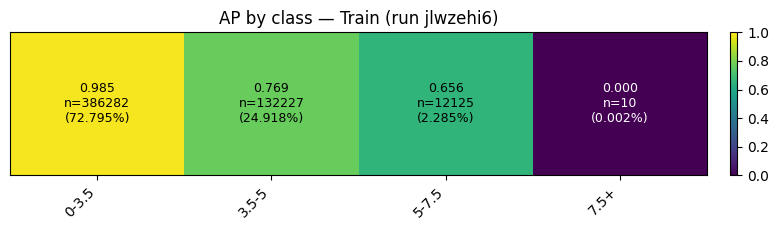

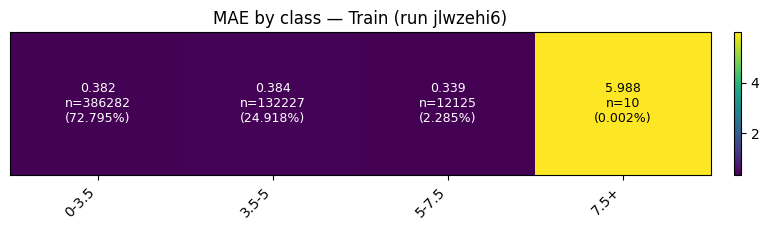

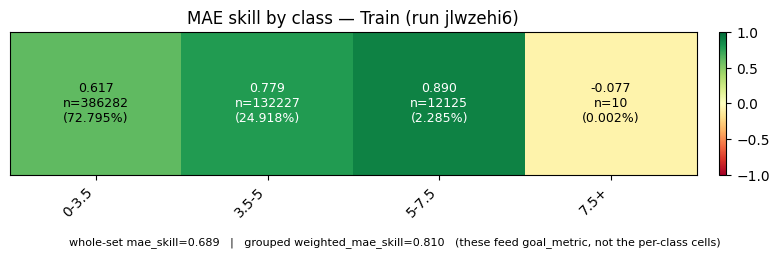

In [8]:
plot_all_heatmaps(y_train, pprop_train, m_train, pearson_m_train, class_names,
                   "train", "Train", SAVE_TRAIN_FIGS)

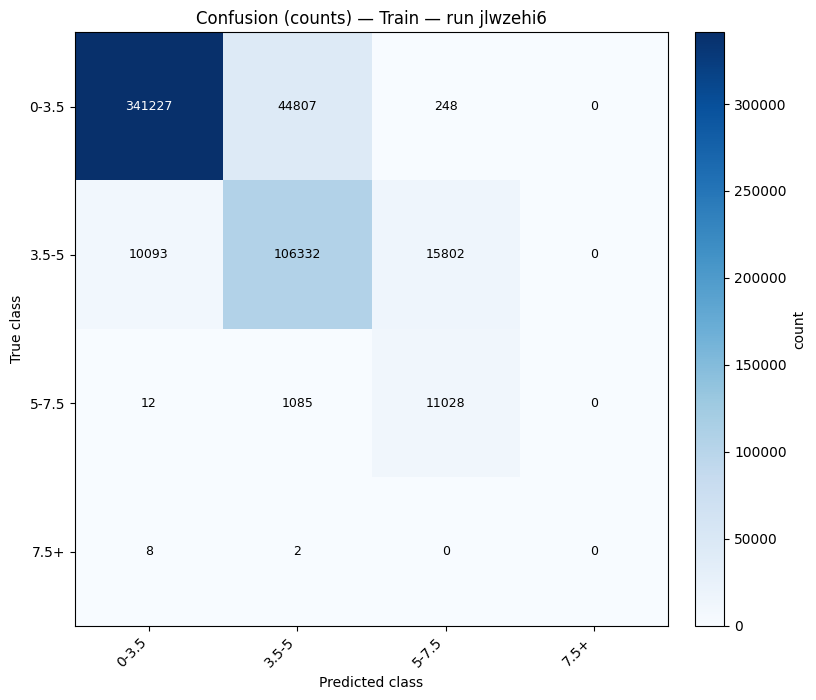

In [9]:
plot_split_confusion_matrix(y_train, preds_train, class_names, "train", "Train", SAVE_TRAIN_FIGS)

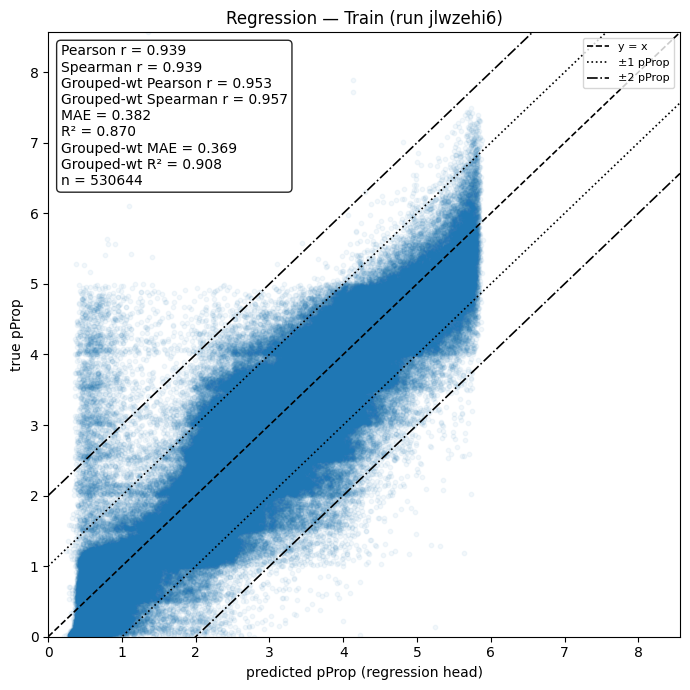

In [10]:
plot_regression_scatter_whole(pprop_train, pred_pprop_train, y_train, "train", "Train", SAVE_TRAIN_FIGS)

# Validation

Every figure below is computed on this run's **held-out validation** set (the
same split reconstructed from the checkpoint's own `config["split_dir"]`).
Set `SAVE_VAL_FIGS = True` to write each one to
`plots/{run_id}/val/{figure_name}.png`.

In [12]:
SAVE_VAL_FIGS = False  # <-- set True to save every Validation figure below to disk

probs_val, preds_val, pred_pprop_val = compute_split_predictions(X_val, E_val)

In [13]:
m_val, pearson_m_val = print_metrics_table(
    y_val, pprop_val, probs_val, pred_pprop_val, class_names, "Validation", ckpt_compare=ckpt
)

Validation per-class (AP + MAE; 7.5+ shown but excluded from *_obj):


,n,ap,mae
class,,,
0-3.5,68168,0.958169,0.463372
3.5-5,23334,0.678652,0.645246
5-7.5,1653,0.247773,1.389179
7.5+,36,0.000320,6.756303



Validation aggregate:


macro_ap_obj          0.628198
weighted_ap_obj       0.875548
weighted_ap           0.875210
mae                   0.527764
weighted_mae          0.833706
mae_skill             0.568983
weighted_mae_skill    0.577702
pearson               0.851712
pearson_weighted      0.737679
ap_star               0.751873
pearson_star          0.794695
mae_skill_star        0.573343
goal_metric           1.435892
dtype: float64


Validation goal-metric decomposition vs. checkpoint-reported (training time):
  ap_star        = 0.7519  (ckpt: 0.751873384644255)
  pearson_star   = 0.7947  (ckpt: 0.7946954268748446)
  mae_skill_star = 0.5733  (ckpt: 0.57334253986076)
  goal_metric    = 1.4359  (ckpt: 1.4358923680120572)


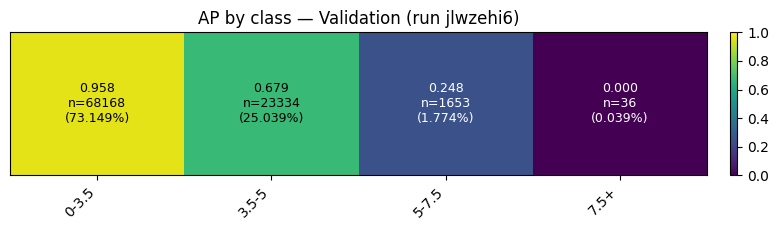

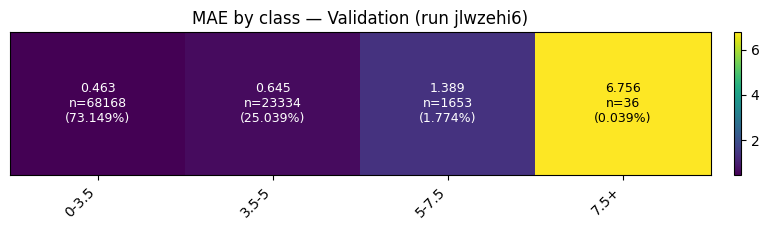

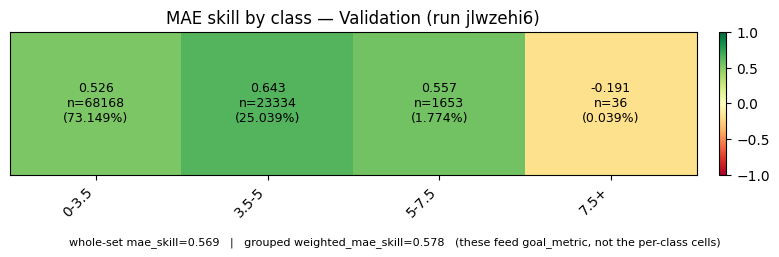

In [14]:
plot_all_heatmaps(y_val, pprop_val, m_val, pearson_m_val, class_names,
                   "val", "Validation", SAVE_VAL_FIGS)

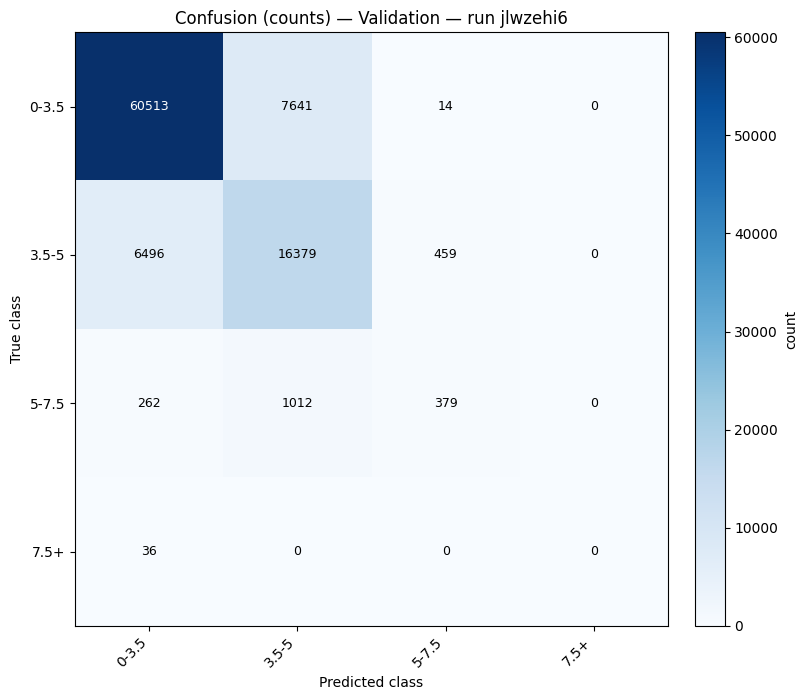

In [15]:
plot_split_confusion_matrix(y_val, preds_val, class_names, "val", "Validation", SAVE_VAL_FIGS)

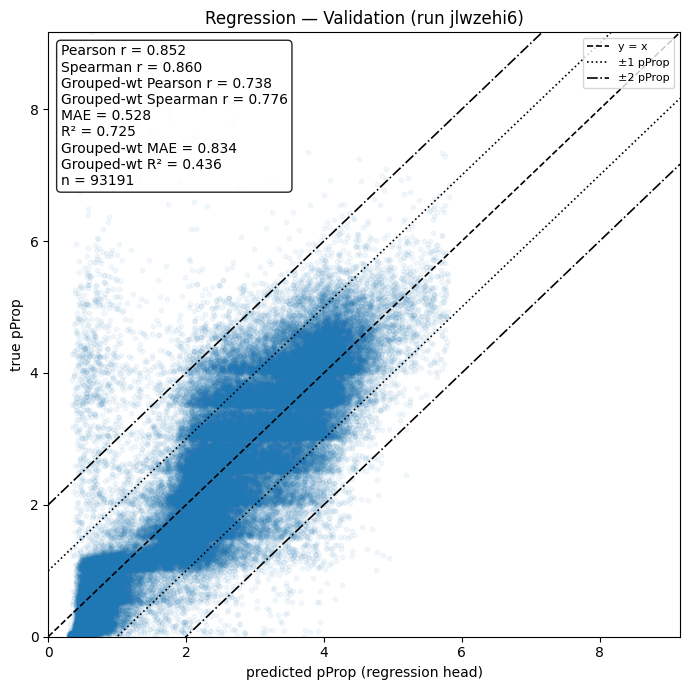

In [16]:
plot_regression_scatter_whole(pprop_val, pred_pprop_val, y_val, "val", "Validation", SAVE_VAL_FIGS)

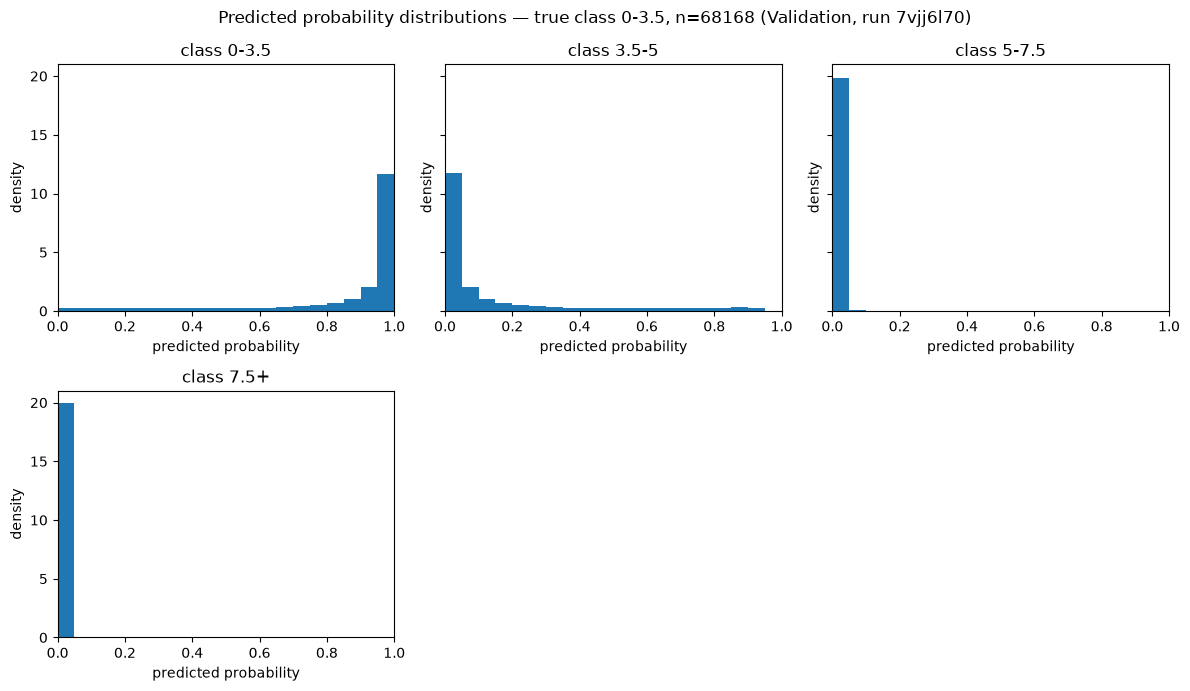

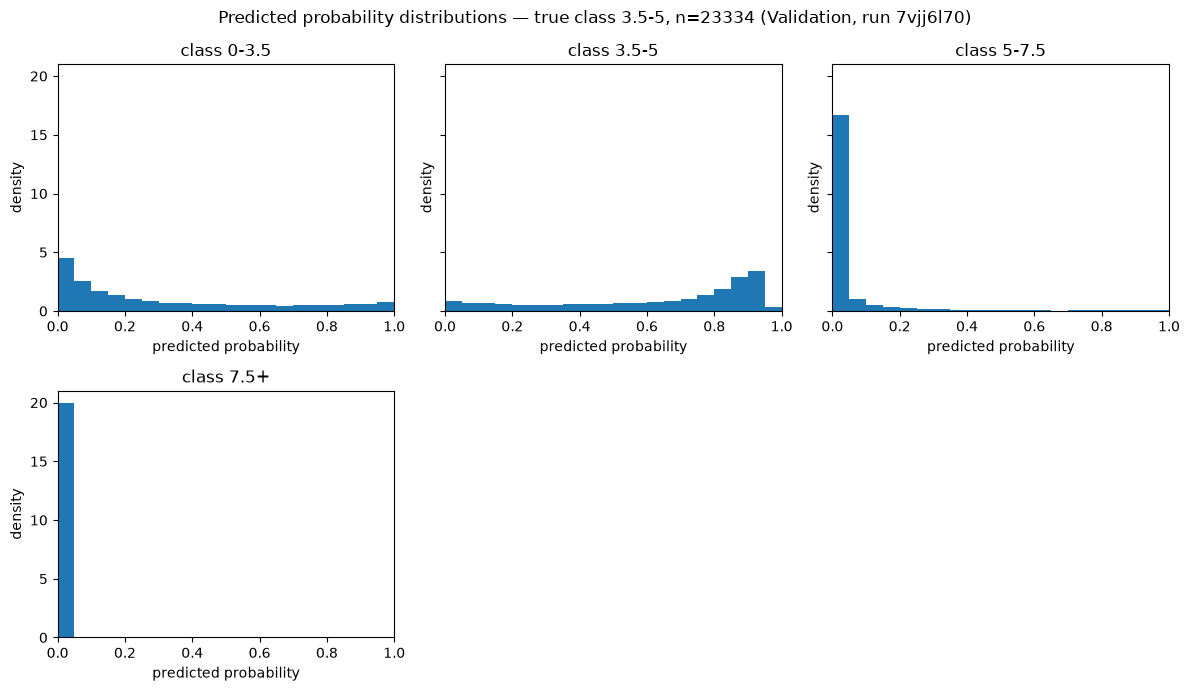

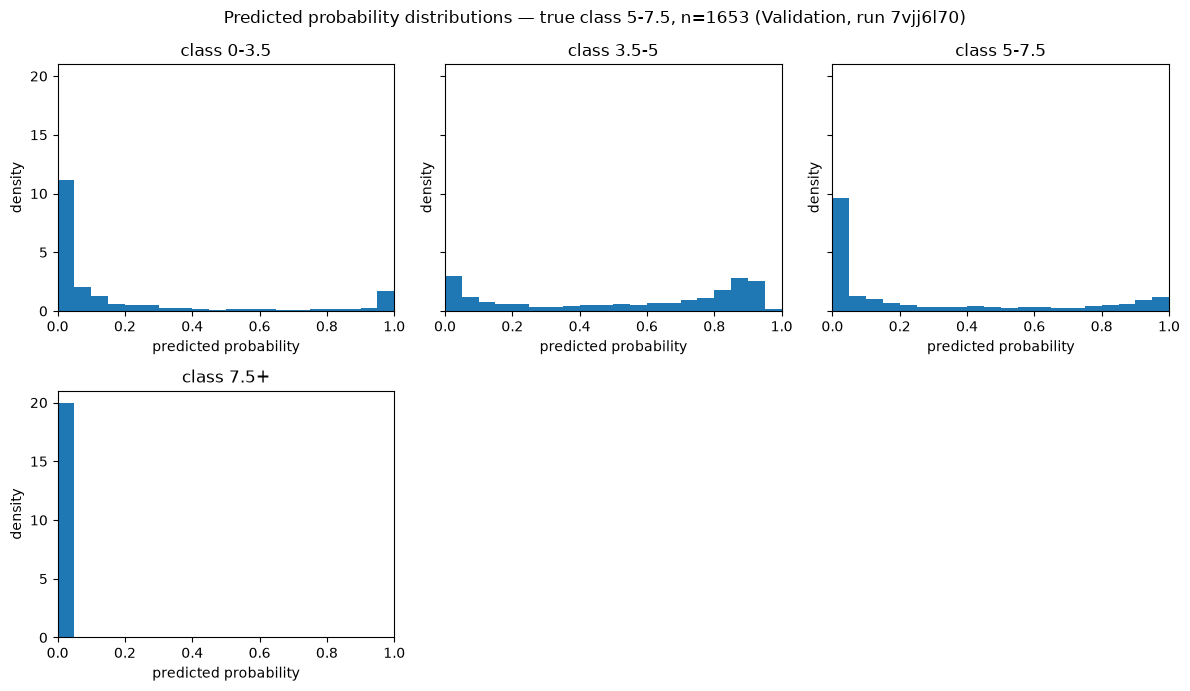

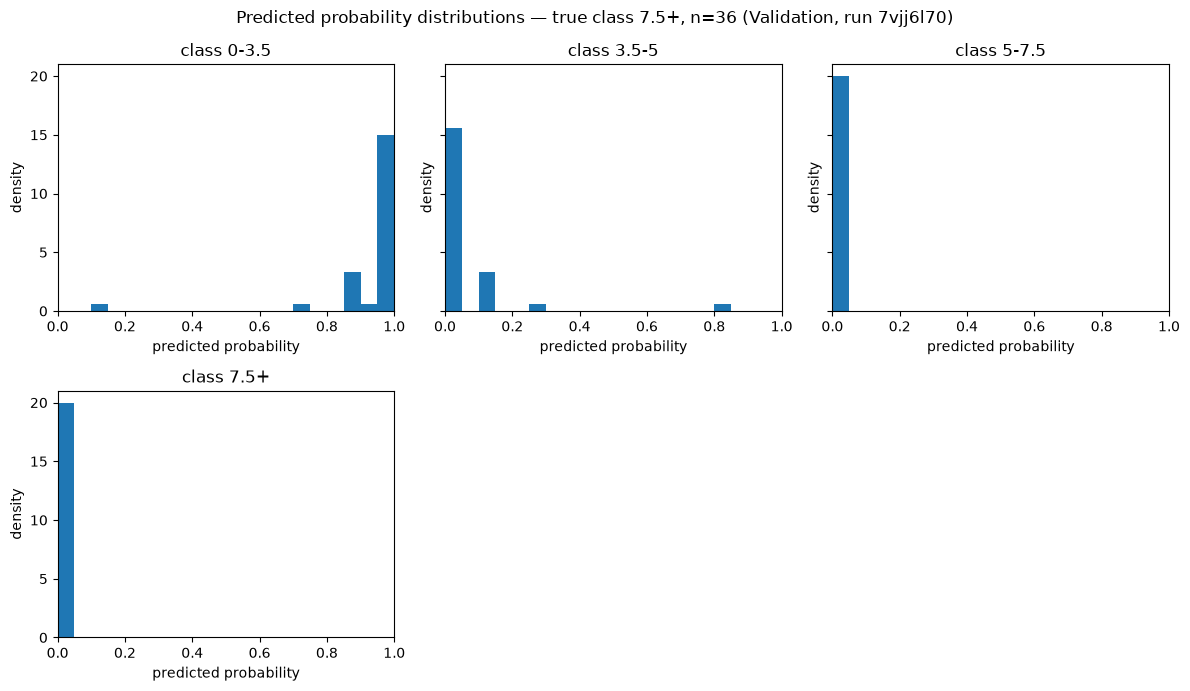

In [16]:
plot_prob_dist_per_class(y_val, probs_val, class_names, "val", "Validation", SAVE_VAL_FIGS)